# Test Model

This acts as the first version of our model, where we will be splitting the data, creating a class to train/validate the data, and finally test a few different configurations of our model.


## Setting Up the Data

Before we begin splitting up the data, we first need to load in our nhanes_model_ready file and see what kind of data we are working with

In [2]:
#Libraries for Code
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report, mean_absolute_error, mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import pickle
import os
import pandas as pd

2026-05-01 13:08:16.196346: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
/Users/jeffpinarchick/opt/anaconda3/envs/py311/lib/python3.11/site-packages/requests/__init__.py:86: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(


In [3]:
#Importing the Data

(Full_Data) = pd.read_csv("../data/processed/nhanes_model_ready_revise.csv")
print(Full_Data.shape)
split = input("What % split do you want for training/testing data?:")
split_idx = int(split)
split_idx = split_idx/100.0
print(split_idx)

(5265, 137)
0.7


So our data appears to focus on 5,625 patients with 137 different categories ranging from race, country of birth, number of children (ages 0-5 and 6-17), and for the case of our study, household income, income:poverty ratio, and tooth records.  While the income to poverty ratio is numerical, unfortunately our household income records are categorical, with each category depicting a different 'level' of household income:

![Household Income Key](/Users/jeffpinarchick/Desktop/DSAN_5300_Final_Project/images/Income_Records_Guide5300.png)

So, looking at the data, it seems like we could take this in 3 separate ways: First, use a multi-class categorical model to predict the 'income' level of patients with tooth records, a binary classification model to determine if someone is 'above' or 'below' the income:poverty ratio (where above 1 = not in poverty and below 1 = in poverty), and finally a linear model to determine the income:poverty ratio of a patient based on their tooth records.

### Measuring Tooth Records

In order to determine the 'tooth health' of an individual, we used the data's DMFT score, which is a scoring system that represents the sum of decayed(D), missing(M), and filled-in(F) teeth that a subject has.  For example, if Patient Jeff has 2 teeth filled in, and 1 tooth decayed from cavities, then he would have a score of 3.  Thus, if we were to make an early prediction, it would be that as the DMFT score approaches 0, the income:poverty rate/household income class should increase (having negative correlation with each other).

In [4]:
#Splitting The Data
task = (f'{input("Choose A Task That You Want to Use (multiclass, binary, or regression)")}')
X_raw = Full_Data[['dmft_score']].values
print(task)
print(X_raw)
if task == 'multiclass':
    valid_codes = sorted([c for c in Full_Data['household_income'].dropna().unique() if c not in [77,99]])
    code_map = {v: i for i,v in enumerate(valid_codes)}
    mask = Full_Data['household_income'].isin(valid_codes)
    X_raw = Full_Data.loc[mask, ['dmft_score']].values
    Y_raw = Full_Data.loc[mask, 'household_income'].map(code_map).values
    n_classes = len(valid_codes)
elif task == 'binary':
    Y_raw = (Full_Data['income_poverty_ratio'] > 1).astype(int).values
    n_classes = 2
elif task == 'regression':
    Y_raw = Full_Data['income_poverty_ratio'].values
    n_classes = 1

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_raw)
X_train, X_temp, Y_train, Y_temp = train_test_split(X_scaled, Y_raw, train_size=split_idx, random_state=42)
X_valid, X_Test, Y_valid, Y_Test = train_test_split(X_temp, Y_temp, test_size=0.50, random_state=42)
print(f"Task: {task} | Training Data Length: {len(X_train)} | Validation Data Length: {len(X_valid)} | Testing Data Length: {len(X_Test)}")
if task == 'multiclass':
    print(f"Number of classes: {n_classes}")

multiclass
[[14]
 [ 0]
 [28]
 ...
 [ 0]
 [ 1]
 [10]]
Task: multiclass | Training Data Length: 3336 | Validation Data Length: 715 | Testing Data Length: 715
Number of classes: 14


In [5]:
#Making the Class
class DentalClassifier:
    def __init__(self, params):
        self.verbose = True
        default_params = {'l1_reg': 0.0, 'l2_reg': 0.0, 'dropout_rate': 0.0, 'hu1': 256, 'hu2': 128, 'hu3': 64,
                          'learning_rate': 0.001, 'epochs': 100, 'batch_size': 32, 'patience': 10, 'activation': 'relu', 'optimizer': 'adam',
                          'task': task, 'n_classes': n_classes, 'n_features': X_train.shape[1]}
        for key, val in default_params.items():
            setattr(self, key, val)
        for key, val in params.items():
            setattr(self, key, val)
        self.build_model()
        self.history = None

    def build_model(self):
        model = keras.Sequential()
        model.add(layers.Dense(self.hu1, input_shape=(self.n_features,), activation = self.activation, kernel_regularizer = keras.regularizers.L1L2(l1=self.l1_reg, l2=self.l2_reg)))
        model.add(layers.Dropout(self.dropout_rate))
        model.add(layers.Dense(self.hu2, activation = self.activation, kernel_regularizer = keras.regularizers.L1L2(l1=self.l1_reg, l2=self.l2_reg)))
        model.add(layers.Dropout(self.dropout_rate))
        model.add(layers.Dense(self.hu3, activation = self.activation, kernel_regularizer = keras.regularizers.L1L2(l1=self.l1_reg, l2=self.l2_reg)))
        model.add(layers.Dropout(self.dropout_rate))
        if self.task == 'multiclass':
            model.add(layers.Dense(self.n_classes, activation='softmax'))
            loss = 'sparse_categorical_crossentropy'
            metrics=['accuracy']
        elif self.task == 'binary':
            model.add(layers.Dense(1, activation = 'sigmoid'))
            loss = 'binary_crossentropy'
            metrics = ['accuracy']
        elif self.task == 'regression':
            model.add(layers.Dense(1, activation = 'linear'))
            loss='mse'
            metrics = ['mae']
        if self.optimizer == 'adam':
            opt = keras.optimizers.Adam(learning_rate = self.learning_rate)
        elif self.optimizer == 'sgd':
            opt = keras.optimizers.SGD(learning_rate = self.learning_rate)
        elif self.optimizer == 'rmsprop':
            opt = keras.optimizers.RMSprop(learning_rate=self.learning_rate)
        else:
            opt = self.optimizer
        model.compile(optimizer = opt, loss = loss, metrics = metrics)
        self.model = model
        print("Model Architecture:")
        model.summary()
    
    def train(self):
        stop_target = input("What Would You Like To Track? (accuracy, loss, val_accuracy, val_loss, mae, or val_mae):")
        mode_map = {'accuracy': 'max', 'val_accuracy': 'max', 'loss': 'min', 'val_loss': 'min', 'mae': 'min', 'val_mae': 'min'}
        mode = mode_map.get(stop_target, 'auto')
        early_stopping = keras.callbacks.EarlyStopping(monitor=stop_target, patience=self.patience, restore_best_weights=True, mode=mode, verbose=1)
        self.history = self.model.fit(X_train, Y_train, batch_size=self.batch_size, epochs = self.epochs, validation_data = (X_valid, Y_valid), callbacks = [early_stopping], verbose=1)
        return self.history
    
    def report(self, save_model=True, model_name = "Testing Model"):
        if self.history is None:
            print("Train the Model First.")
            return
        fig, axes = plt.subplots(2,3, figsize=(18,12))
        axes[0, 0].plot(self.history.history['loss'], label='Training Loss')
        axes[0, 0].plot(self.history.history['val_loss'], label='Validation Loss')
        axes[0, 0].set_title('Model Loss')
        axes[0, 0].set_xlabel('Epoch')
        axes[0, 0].set_ylabel('Loss')
        axes[0, 0].legend()
        axes[0, 0].grid(True)

        if self.task in ('multiclass', 'binary'):
            axes[0, 1].plot(self.history.history['accuracy'], label='Training Accuracy')
            axes[0, 1].plot(self.history.history['val_accuracy'], label='Validation Accuracy')
            axes[0, 1].set_title('Model Accuracy')
            axes[0, 1].set_xlabel('Epoch')
            axes[0, 1].set_ylabel('Accuracy')
            axes[0, 1].legend()
            axes[0, 1].grid(True)

            if self.task == 'multiclass':
                Y_train_pred = np.argmax(self.model.predict(X_train, verbose = 0), axis=1)
                Y_val_pred   = np.argmax(self.model.predict(X_valid, verbose=0), axis=1)
                Y_test_pred  = np.argmax(self.model.predict(X_Test,  verbose=0), axis=1)
            else:
                Y_train_pred = (self.model.predict(X_train, verbose=0) > 0.5).astype(int).flatten()
                Y_val_pred   = (self.model.predict(X_valid, verbose=0) > 0.5).astype(int).flatten()
                Y_test_pred  = (self.model.predict(X_Test,  verbose=0) > 0.5).astype(int).flatten()

            cm_train = confusion_matrix(Y_train, Y_train_pred)
            cm_val = confusion_matrix(Y_valid, Y_val_pred)
            cm_test = confusion_matrix(Y_Test, Y_test_pred)

            sns.heatmap(cm_train, annot=True, fmt='d', cmap='Blues', ax=axes[1, 0])
            axes[1, 0].set_title('Training Set Confusion Matrix')
            axes[1, 0].set_xlabel('Predicted')
            axes[1, 0].set_ylabel('Actual')

            sns.heatmap(cm_val, annot=True, fmt='d', cmap='Blues', ax=axes[1, 1])
            axes[1, 1].set_title('Validation Set Confusion Matrix')
            axes[1, 1].set_xlabel('Predicted')
            axes[1, 1].set_ylabel('Actual')

            sns.heatmap(cm_test, annot=True, fmt='d', cmap='Blues', ax=axes[1, 2])
            axes[1, 2].set_title('Test Set Confusion Matrix')
            axes[1, 2].set_xlabel('Predicted')
            axes[1, 2].set_ylabel('Actual')

            axes[0, 2].remove()

            plt.tight_layout()
            plt.show()

            print(classification_report(Y_train, Y_train_pred))
            print(classification_report(Y_valid, Y_val_pred))
            print(classification_report(Y_Test, Y_test_pred))
            train_acc = np.mean(Y_train == Y_train_pred)
            val_acc = np.mean(Y_valid == Y_val_pred)
            test_acc = np.mean(Y_Test == Y_test_pred)
            print(f"Training Accuracy:   {train_acc:.4f}")
            print(f"Validation Accuracy: {val_acc:.4f}")
            print(f"Test Accuracy:       {test_acc:.4f}")
            return {'train_acc': train_acc, 'val_acc': val_acc, 'test_acc': test_acc}
        
        elif self.task == 'regression':
            Y_train_pred = self.model.predict(X_train, verbose=0).flatten()
            Y_val_pred   = self.model.predict(X_valid, verbose=0).flatten()
            Y_test_pred  = self.model.predict(X_Test,  verbose=0).flatten()
            for ax, Y_true, Y_pred, title in zip([axes[1, 0], axes[1, 1], axes[1, 2]], [Y_train,    Y_valid,    Y_Test], [Y_train_pred, Y_val_pred, Y_test_pred], ['Training', 'Validation', 'Test']):
                ax.scatter(Y_true, Y_pred, alpha=0.3, s=10, color='steelblue')
                min_val = min(Y_true.min(), Y_pred.min())
                max_val = max(Y_true.max(), Y_pred.max())
                ax.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=1.5, label='Perfect Fit')
                ax.set_title(f'{title} Set: Actual vs Predicted')
                ax.set_xlabel('Actual Income:Poverty Ratio')
                ax.set_ylabel('Predicted Income:Poverty Ratio')
                ax.legend()
                ax.grid(True)
            axes[0, 1].clear()
            axes[0, 1].plot(self.history.history['mae'], label='Training MAE')
            axes[0, 1].plot(self.history.history['val_mae'], label='Validation MAE')
            axes[0, 1].set_title('Model MAE')
            axes[0, 1].set_xlabel('Epoch')
            axes[0, 1].set_ylabel('MAE')
            axes[0, 1].legend()
            axes[0, 1].grid(True)
            axes[0, 2].remove()
            plt.tight_layout()
            plt.show()

            train_mae  = mean_absolute_error(Y_train, Y_train_pred)
            val_mae    = mean_absolute_error(Y_valid, Y_val_pred)
            test_mae   = mean_absolute_error(Y_Test,  Y_test_pred)
            train_rmse = np.sqrt(mean_squared_error(Y_train, Y_train_pred))
            val_rmse   = np.sqrt(mean_squared_error(Y_valid, Y_val_pred))
            test_rmse  = np.sqrt(mean_squared_error(Y_Test,  Y_test_pred))

            print(f"Training   — MAE: {train_mae:.4f} | RMSE: {train_rmse:.4f}")
            print(f"Validation — MAE: {val_mae:.4f} | RMSE: {val_rmse:.4f}")
            print(f"Test       — MAE: {test_mae:.4f} | RMSE: {test_rmse:.4f}")

            return {'train_mae': train_mae, 'val_mae': val_mae, 'test_mae': test_mae,
                    'train_rmse': train_rmse, 'val_rmse': val_rmse, 'test_rmse': test_rmse}

        



            

Model Architecture:


/Users/jeffpinarchick/opt/anaconda3/envs/py311/lib/python3.11/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 14)             │           462 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,054 (43.18 KB)

 Trainable params: 11,054 (43.18 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
105/105 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.1292 - loss: 2.6113 - val_accuracy: 0.1958 - val_loss: 2.5816
Epoch 2/50
105/105 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.1912 - loss: 2.5576 - val_accuracy: 0.1958 - val_loss: 2.5395
Epoch 3/50
105/105 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.1921 - loss: 2.5237 - val_accuracy: 0.1958 - val_loss: 2.5127
Epoch 4/50
105/105 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.1921 - loss: 2.5009 - val_accuracy: 0.1958 - val_loss: 2.4954
Epoch 5/50
105/105 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.1921 - loss: 2.4867 - val_accuracy: 0.1958 - val_loss: 2.4845
Epoch 6/50
105/105 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.1921 - loss: 2.4770 - val_accuracy: 0.1958 - val_loss: 2.4779
Epoch 7/50
105/105 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.1921 - loss: 2.4734 - val_accuracy: 0.1958 - val_loss: 2.4743
Epoch 8/50
105/105 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.1921 - loss: 2.4695 - val_accuracy: 0.

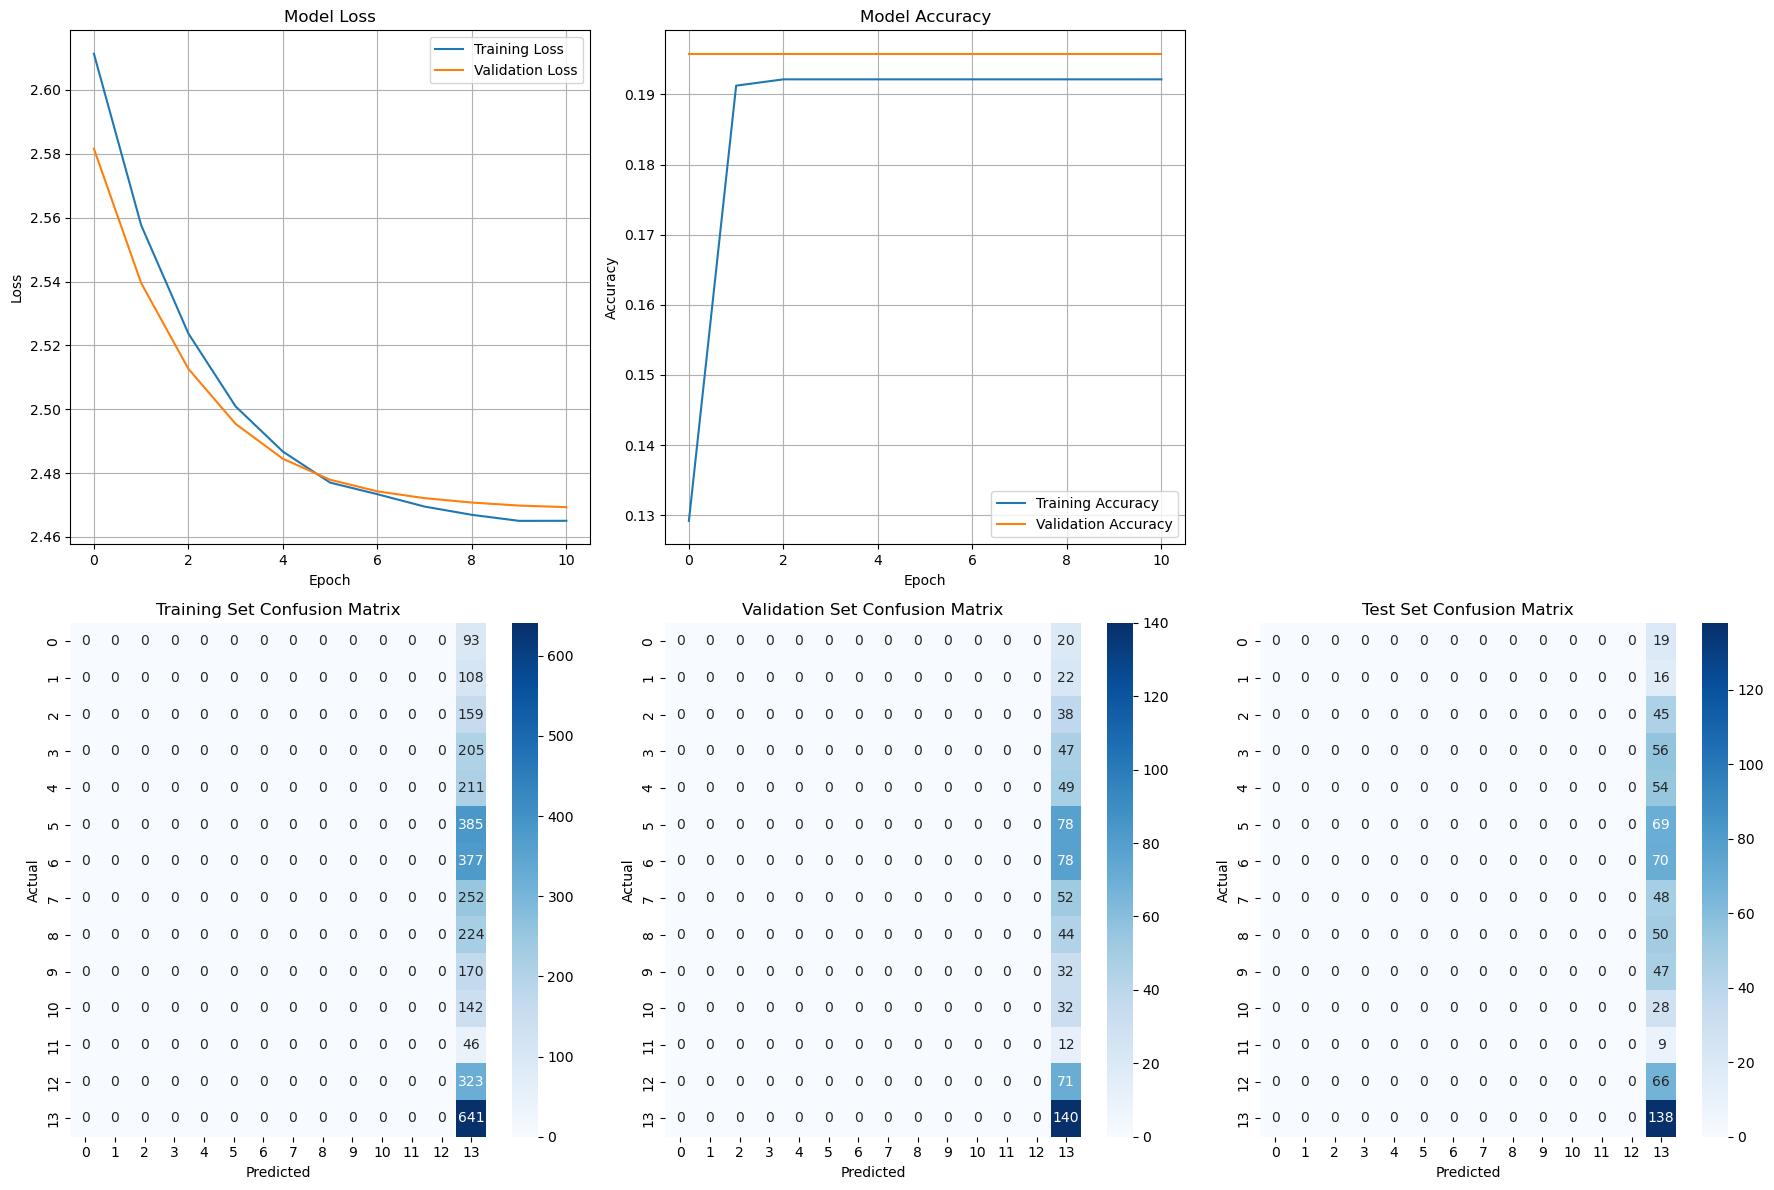

              precision    recall  f1-score   support

           0       0.00      0.00      0.00        93
           1       0.00      0.00      0.00       108
           2       0.00      0.00      0.00       159
           3       0.00      0.00      0.00       205
           4       0.00      0.00      0.00       211
           5       0.00      0.00      0.00       385
           6       0.00      0.00      0.00       377
           7       0.00      0.00      0.00       252
           8       0.00      0.00      0.00       224
           9       0.00      0.00      0.00       170
          10       0.00      0.00      0.00       142
          11       0.00      0.00      0.00        46
          12       0.00      0.00      0.00       323
          13       0.19      1.00      0.32       641

    accuracy                           0.19      3336
   macro avg       0.01      0.07      0.02      3336
weighted avg       0.04      0.19      0.06      3336

              precision  

/Users/jeffpinarchick/opt/anaconda3/envs/py311/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/jeffpinarchick/opt/anaconda3/envs/py311/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/jeffpinarchick/opt/anaconda3/envs/py311/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _war

In [5]:
#First Test (multiclass, val_accuracy)
config1 = {'l1_reg': 0.0, 'l2_reg': 0.0, 'dropout_rate': 0.2, 'hu1': 128, 'hu2': 64,
           'hu3': 32, 'activation': 'softmax', 'optimizer': 'adam', 'learning_rate': 0.001,
           'epochs': 50, 'batch_size': 32, 'patience': 10,
           'task': task, 'n_classes': n_classes, 'n_features': X_train.shape[1]}
model1 = DentalClassifier(config1)
model1.train()
results1 = model1.report(model_name="model1_baseline")
print(results1)

/Users/jeffpinarchick/opt/anaconda3/envs/py311/lib/python3.11/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model Architecture:


Model: "sequential_12"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_44 (Dense)                │ (None, 128)            │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_33 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_45 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_34 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_46 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_35 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_47 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,625 (41.50 KB)

 Trainable params: 10,625 (41.50 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
116/116 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.6372 - loss: 0.6546 - val_accuracy: 0.6367 - val_loss: 0.6536
Epoch 2/50
116/116 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6456 - loss: 0.6465 - val_accuracy: 0.6367 - val_loss: 0.6504
Epoch 3/50
116/116 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6456 - loss: 0.6458 - val_accuracy: 0.6367 - val_loss: 0.6495
Epoch 4/50
116/116 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6456 - loss: 0.6454 - val_accuracy: 0.6367 - val_loss: 0.6499
Epoch 5/50
116/116 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6456 - loss: 0.6444 - val_accuracy: 0.6367 - val_loss: 0.6506
Epoch 6/50
116/116 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.6456 - loss: 0.6435 - val_accuracy: 0.6367 - val_loss: 0.6513
Epoch 7/50
116/116 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6456 - loss: 0.6432 - val_accuracy: 0.6367 - val_loss: 0.6514
Epoch 8/50
116/116 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6456 - loss: 0.6430 - val_accuracy: 0.

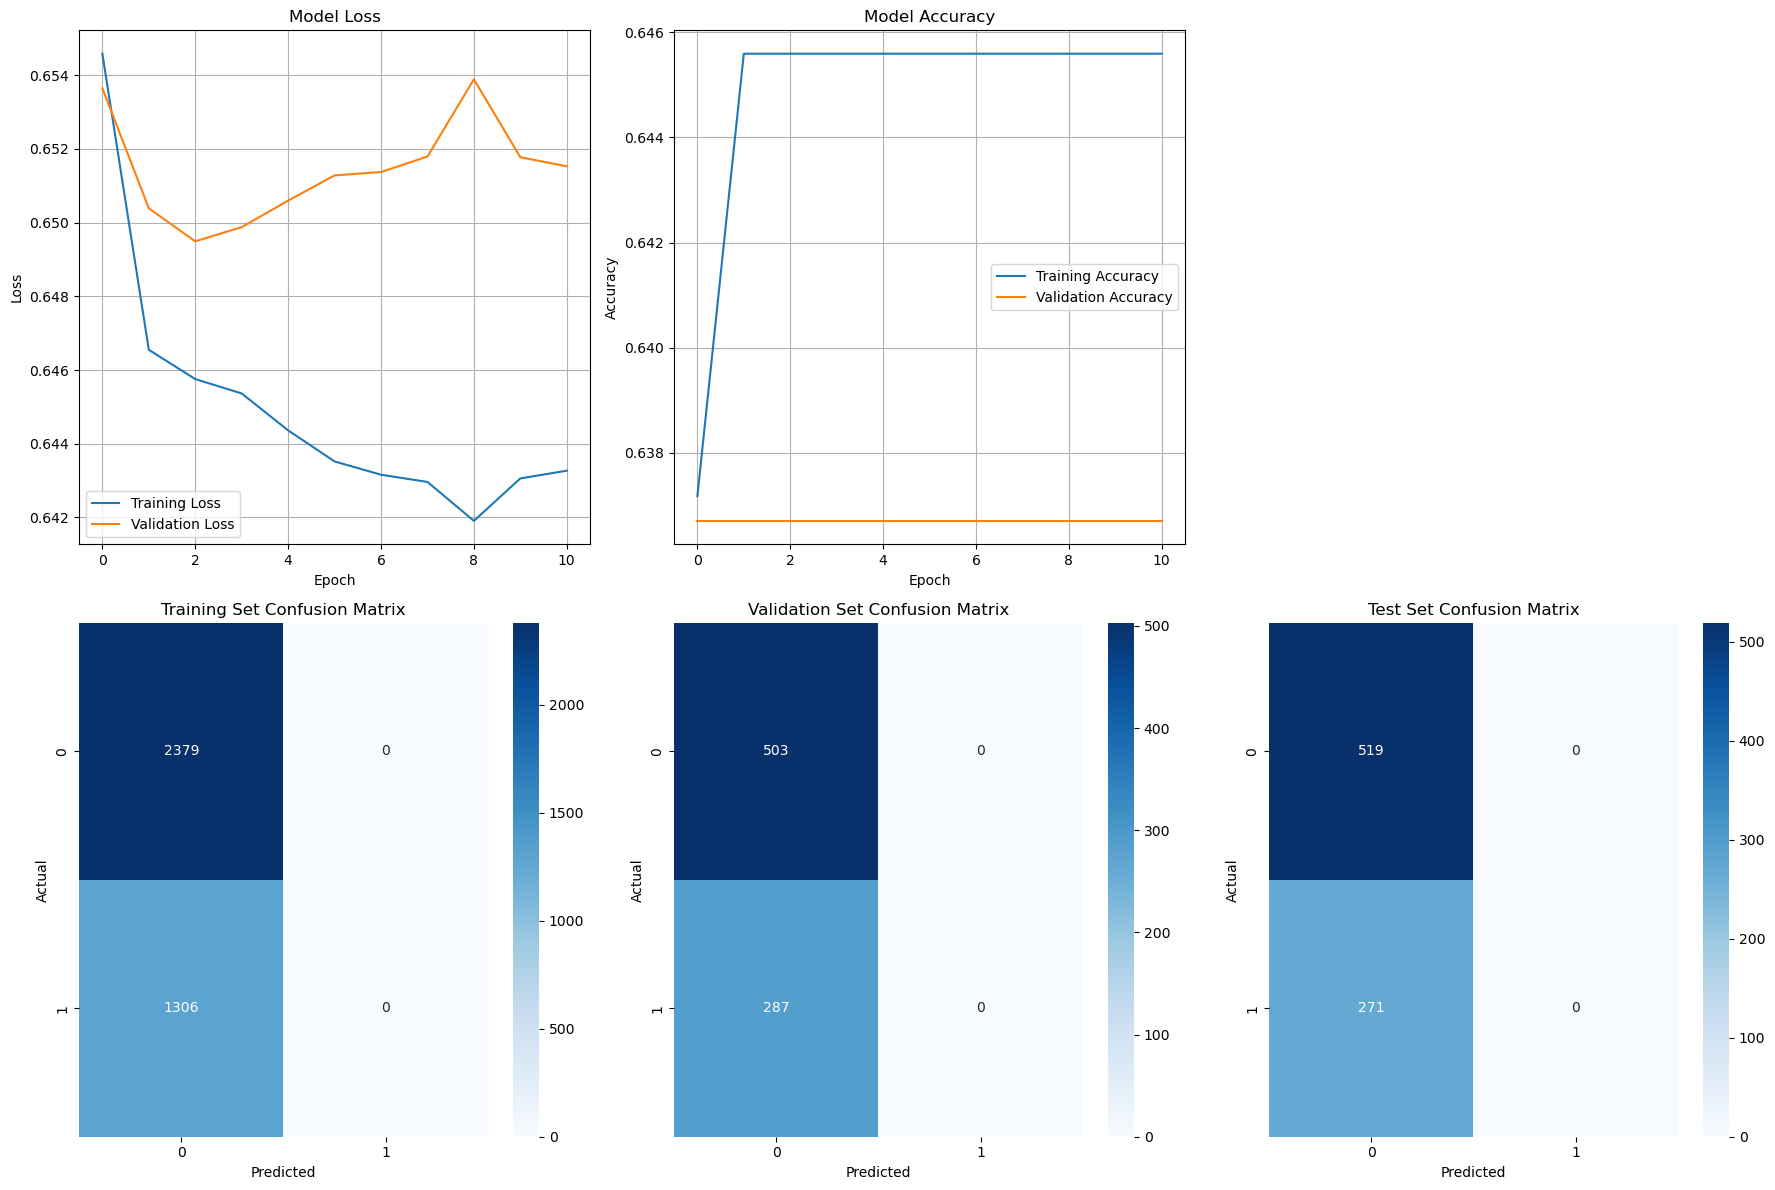

              precision    recall  f1-score   support

           0       0.65      1.00      0.78      2379
           1       0.00      0.00      0.00      1306

    accuracy                           0.65      3685
   macro avg       0.32      0.50      0.39      3685
weighted avg       0.42      0.65      0.51      3685

              precision    recall  f1-score   support

           0       0.64      1.00      0.78       503
           1       0.00      0.00      0.00       287

    accuracy                           0.64       790
   macro avg       0.32      0.50      0.39       790
weighted avg       0.41      0.64      0.50       790

              precision    recall  f1-score   support

           0       0.66      1.00      0.79       519
           1       0.00      0.00      0.00       271

    accuracy                           0.66       790
   macro avg       0.33      0.50      0.40       790
weighted avg       0.43      0.66      0.52       790

Training Accuracy: 

/Users/jeffpinarchick/opt/anaconda3/envs/py311/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/jeffpinarchick/opt/anaconda3/envs/py311/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/jeffpinarchick/opt/anaconda3/envs/py311/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _war

In [53]:
#Second Test: Binary (val_accuracy)
config2 = {'l1_reg': 0.0, 'l2_reg': 0.0, 'dropout_rate': 0.2, 'hu1': 128, 'hu2': 64,
           'hu3': 32, 'activation': 'relu', 'optimizer': 'adam', 'learning_rate': 0.001,
           'epochs': 50, 'batch_size': 32, 'patience': 10,
           'task': task, 'n_classes': n_classes, 'n_features': X_train.shape[1]}
model2 = DentalClassifier(config2)
model2.train()
results2 = model2.report(model_name="model2_baseline")
print(results2)

Model Architecture:


/Users/jeffpinarchick/opt/anaconda3/envs/py311/lib/python3.11/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_11"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_40 (Dense)                │ (None, 128)            │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_30 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_41 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_31 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_42 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_32 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_43 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,625 (41.50 KB)

 Trainable params: 10,625 (41.50 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
116/116 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 3.8691 - mae: 1.5632 - val_loss: 2.3169 - val_mae: 1.2420
Epoch 2/50
116/116 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 2.4596 - mae: 1.2906 - val_loss: 2.2628 - val_mae: 1.2486
Epoch 3/50
116/116 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 2.4391 - mae: 1.2891 - val_loss: 2.2641 - val_mae: 1.2660
Epoch 4/50
116/116 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 2.4046 - mae: 1.2820 - val_loss: 2.2752 - val_mae: 1.2456
Epoch 5/50
116/116 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 2.3994 - mae: 1.2782 - val_loss: 2.2763 - val_mae: 1.2407
Epoch 6/50
116/116 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 2.4011 - mae: 1.2847 - val_loss: 2.3318 - val_mae: 1.2149
Epoch 7/50
116/116 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 2.4080 - mae: 1.2831 - val_loss: 2.2960 - val_mae: 1.2304
Epoch 8/50
116/116 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 2.3708 - mae: 1.2681 - val_loss: 2.2644 - val_mae: 1.2666
Epoch 9/50
116/116 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - lo

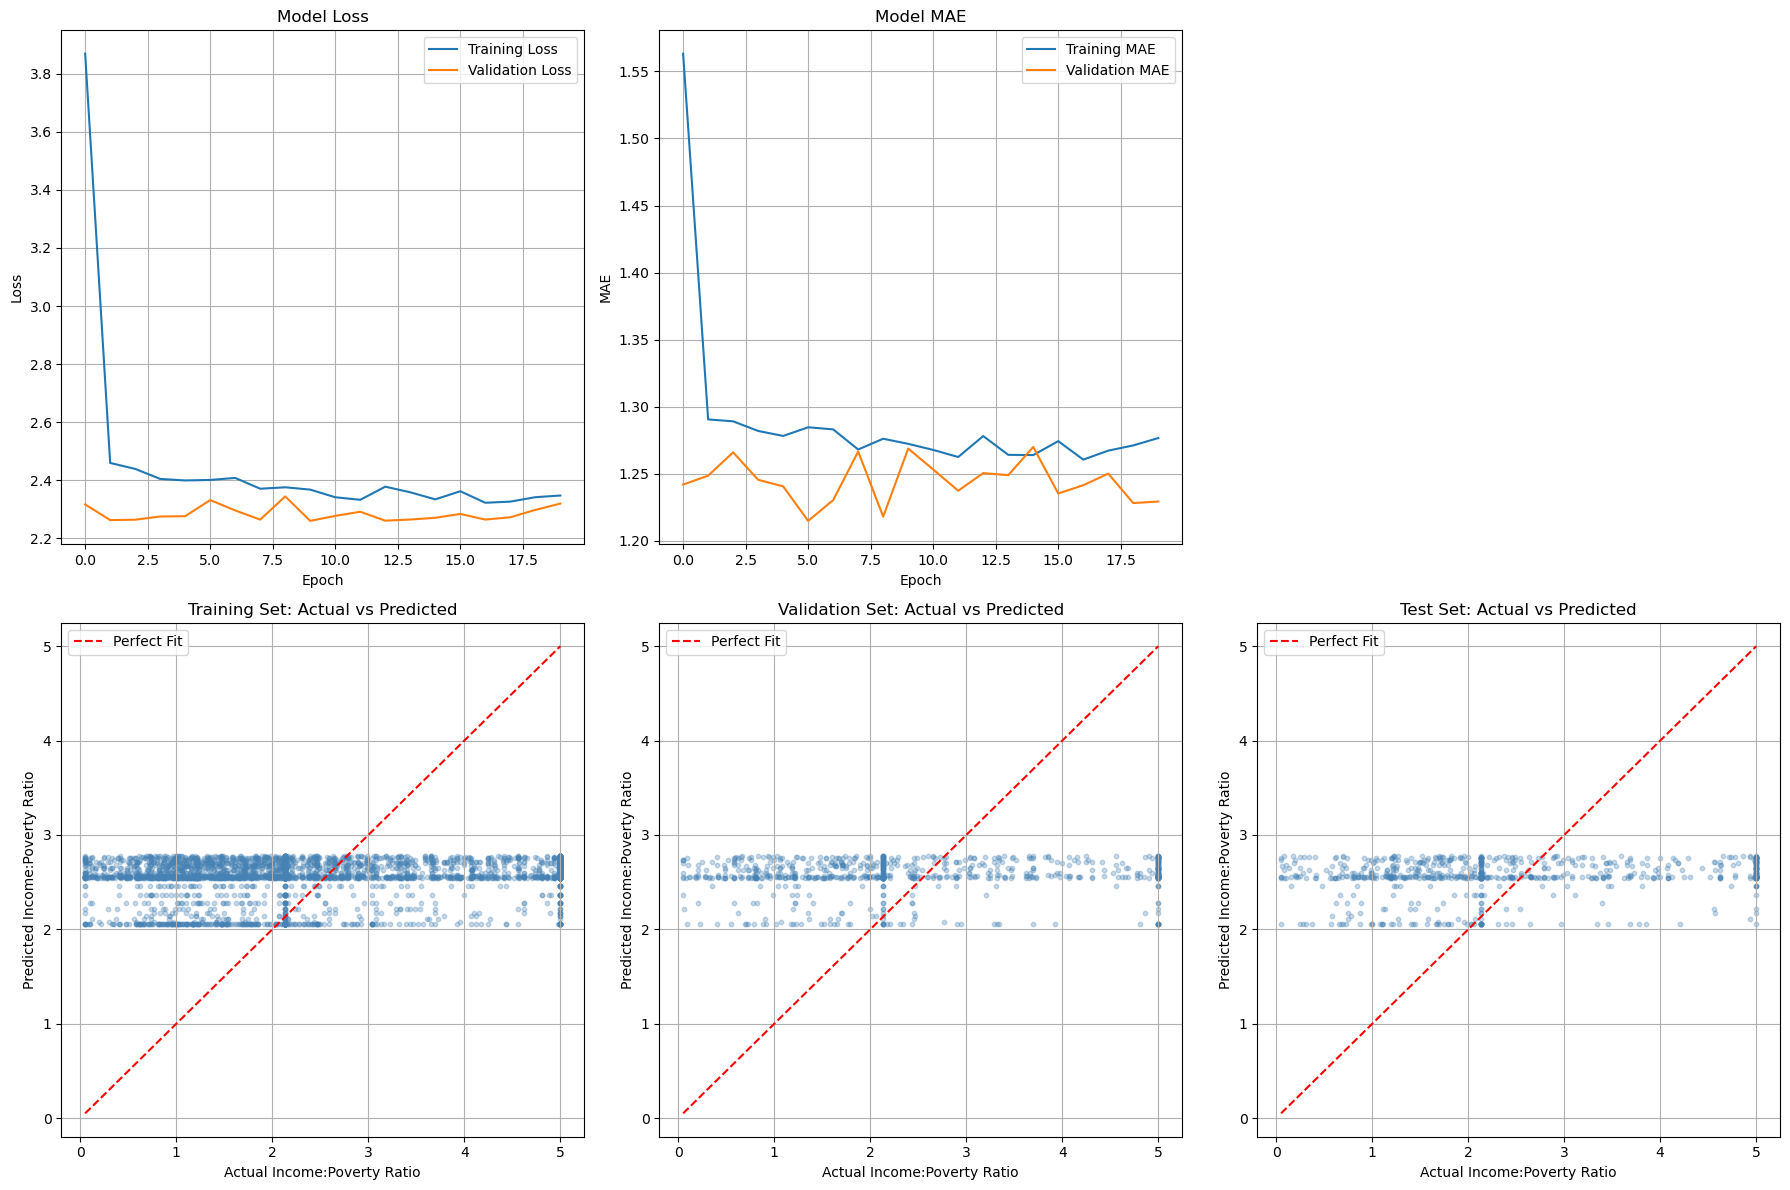

Training   — MAE: 1.2635 | RMSE: 1.4918
Validation — MAE: 1.2688 | RMSE: 1.5034
Test       — MAE: 1.2024 | RMSE: 1.4392
{'train_mae': 1.2634816952321068, 'val_mae': 1.2688282132088384, 'test_mae': 1.202389672617369, 'train_rmse': 1.4918226815323694, 'val_rmse': 1.503379772200437, 'test_rmse': 1.4391881220954161}


In [ ]:
#Third Test (regression, val_mae)
config3 = {'l1_reg': 0.0, 'l2_reg': 0.0, 'dropout_rate': 0.2, 'hu1': 128, 'hu2': 64,
           'hu3': 32, 'activation': 'relu', 'optimizer': 'adam', 'learning_rate': 0.001,
           'epochs': 50, 'batch_size': 32, 'patience': 10,
           'task': task, 'n_classes': n_classes, 'n_features': X_train.shape[1]}
model3 = DentalClassifier(config3)
model3.train()
results3 = model3.report(model_name="model3_baseline")
print(results3)

### Updating the Model

Ok, so just using one variable to account for every tooth status leads to some... Less than valuable results.  In order to update our model to be comprehensive, let's check all the numeric variables in our data that correlate with our 'income_poverty_ratio', using '0.10' as our threshold for a 'significant' variable

In [6]:
numeric_data = Full_Data.select_dtypes(include=[np.number])
corr = numeric_data.corr()['income_poverty_ratio'].abs().sort_values(ascending=False)
print(corr.head(20))
print(numeric_data.shape[1])

#Checking Dental Variables
dental_cols = [col for col in numeric_data.columns if any(keyword in col.lower() 
               for keyword in ['tooth', 'teeth', 'dmft', 'decay', 'missing', 'filled', 
                               'oral', 'dental', 'OHX', 'ohx', 'molar', 'incisor'])]
print(f"Dental-related numeric columns ({len(dental_cols)}):")
for col in dental_cols:
    print(f"  {col}  |  corr with income_poverty_ratio: {corr.get(col, 'N/A'):.4f}" if col in corr.index else f"  {col}")

income_poverty_ratio              1.000000
log_income_poverty_ratio          0.870977
education_adult                   0.411562
last_dental_visit                 0.285747
self_rated_oral_health            0.277016
target_needs_care                 0.265185
target_poor_selfrated             0.262322
overall_care_recommendation       0.257431
referral_soft_tissue              0.237647
teeth_filled_sound                0.223769
freq_embarrassed_from_mouth       0.220697
marital_status                    0.220175
needed_dental_care_couldnt_get    0.215026
barrier_cost                      0.210707
reason_last_dental_visit          0.201823
treatment_ratio                   0.195980
root_caries_present               0.190651
freq_job_difficulty_from_mouth    0.187725
freq_mouth_aching_past_year       0.187591
had_oral_cancer_exam              0.185320
Name: income_poverty_ratio, dtype: float64
109
Dental-related numeric columns (51):
  has_dental_implant  |  corr with income_poverty_ratio:

In [7]:
threshold = 0.10
useful_dental_columns = [col for col in dental_cols if col in corr.index and corr[col] >= threshold and col not in ['income_poverty_ratio', 'household_income']]

print(f"Dental features with corr >= {threshold}: {len(useful_dental_columns)}")
for col in useful_dental_columns:
    print(f"  {col}: {corr[col]:.4f}")

Dental features with corr >= 0.1: 40
  has_dental_implant: 0.1159
  tooth_02_status: 0.1582
  tooth_03_status: 0.1814
  tooth_04_status: 0.1731
  tooth_05_status: 0.1486
  tooth_06_status: 0.1574
  tooth_07_status: 0.1753
  tooth_08_status: 0.1629
  tooth_09_status: 0.1503
  tooth_10_status: 0.1643
  tooth_11_status: 0.1607
  tooth_12_status: 0.1423
  tooth_13_status: 0.1727
  tooth_14_status: 0.1764
  tooth_15_status: 0.1730
  tooth_18_status: 0.1744
  tooth_19_status: 0.1773
  tooth_20_status: 0.1622
  tooth_21_status: 0.1079
  tooth_22_status: 0.1524
  tooth_23_status: 0.1331
  tooth_24_status: 0.1378
  tooth_25_status: 0.1335
  tooth_26_status: 0.1347
  tooth_27_status: 0.1510
  tooth_28_status: 0.1171
  tooth_29_status: 0.1588
  tooth_30_status: 0.1751
  tooth_31_status: 0.1726
  last_dental_visit: 0.2857
  reason_last_dental_visit: 0.2018
  needed_dental_care_couldnt_get: 0.2150
  self_rated_oral_health: 0.2770
  had_oral_cancer_exam: 0.1853
  when_last_oral_cancer_exam: 0.1663
 

In [8]:
for col in useful_dental_columns:
    print(f"| `{col}` | {corr[col]:.4f} |")

| `has_dental_implant` | 0.1159 |
| `tooth_02_status` | 0.1582 |
| `tooth_03_status` | 0.1814 |
| `tooth_04_status` | 0.1731 |
| `tooth_05_status` | 0.1486 |
| `tooth_06_status` | 0.1574 |
| `tooth_07_status` | 0.1753 |
| `tooth_08_status` | 0.1629 |
| `tooth_09_status` | 0.1503 |
| `tooth_10_status` | 0.1643 |
| `tooth_11_status` | 0.1607 |
| `tooth_12_status` | 0.1423 |
| `tooth_13_status` | 0.1727 |
| `tooth_14_status` | 0.1764 |
| `tooth_15_status` | 0.1730 |
| `tooth_18_status` | 0.1744 |
| `tooth_19_status` | 0.1773 |
| `tooth_20_status` | 0.1622 |
| `tooth_21_status` | 0.1079 |
| `tooth_22_status` | 0.1524 |
| `tooth_23_status` | 0.1331 |
| `tooth_24_status` | 0.1378 |
| `tooth_25_status` | 0.1335 |
| `tooth_26_status` | 0.1347 |
| `tooth_27_status` | 0.1510 |
| `tooth_28_status` | 0.1171 |
| `tooth_29_status` | 0.1588 |
| `tooth_30_status` | 0.1751 |
| `tooth_31_status` | 0.1726 |
| `last_dental_visit` | 0.2857 |
| `reason_last_dental_visit` | 0.2018 |
| `needed_dental_care_cou

As it turns out, we have 40 variables that can be 'useful' in constructing our neural network!  This should have much better results compared to just using DMFT Score, which was not included in our 'useful' variables!

In [10]:
#Updating The Data
task = (f'{input("Choose A Task That You Want to Use (multiclass, binary, or regression)")}')
featured_columns = useful_dental_columns
print(task)
if task == 'multiclass':
    valid_codes = sorted([c for c in Full_Data['household_income'].dropna().unique() if c not in [77,99]])
    code_map = {v: i for i,v in enumerate(valid_codes)}
    mask = Full_Data['household_income'].isin(valid_codes)
    X_raw = Full_Data.loc[mask, featured_columns].fillna(0).values
    Y_raw = Full_Data.loc[mask, 'household_income'].map(code_map).values
    n_classes = len(valid_codes)
elif task == 'binary':
    X_raw = Full_Data[featured_columns].fillna(0).values
    Y_raw = (Full_Data['income_poverty_ratio'] > 1).astype(int).values
    n_classes = 2
elif task == 'regression':
    X_raw = Full_Data[featured_columns].fillna(0).values
    Y_raw = Full_Data['income_poverty_ratio'].values
    n_classes = 1

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_raw)
X_train, X_temp, Y_train, Y_temp = train_test_split(X_scaled, Y_raw, train_size=split_idx, random_state=42)
X_valid, X_Test, Y_valid, Y_Test = train_test_split(X_temp, Y_temp, test_size=0.50, random_state=42)
print(f"Task: {task} | Training Data Length: {len(X_train)} | Validation Data Length: {len(X_valid)} | Testing Data Length: {len(X_Test)}")
if task == 'multiclass':
    print(f"Number of classes: {n_classes}")

regression
Task: regression | Training Data Length: 3685 | Validation Data Length: 790 | Testing Data Length: 790


Since our DentalClassifier is already made, we only need to provide code for our updated tests!

In [20]:
print(X_train.shape[1])

40


Model Architecture:


/Users/jeffpinarchick/opt/anaconda3/envs/py311/lib/python3.11/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_12 (Dense)                │ (None, 256)            │        10,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 14)             │           910 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 52,558 (205.30 KB)

 Trainable params: 52,558 (205.30 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
105/105 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.1874 - loss: 2.5056 - val_accuracy: 0.2168 - val_loss: 2.4075
Epoch 2/50
105/105 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.2188 - loss: 2.4120 - val_accuracy: 0.2154 - val_loss: 2.3940
Epoch 3/50
105/105 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.2146 - loss: 2.3847 - val_accuracy: 0.2210 - val_loss: 2.3658
Epoch 4/50
105/105 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.2254 - loss: 2.3710 - val_accuracy: 0.2224 - val_loss: 2.3734
Epoch 5/50
105/105 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.2254 - loss: 2.3517 - val_accuracy: 0.2210 - val_loss: 2.3544
Epoch 6/50
105/105 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.2395 - loss: 2.3319 - val_accuracy: 0.2252 - val_loss: 2.3618
Epoch 7/50
105/105 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.2410 - loss: 2.3217 - val_accuracy: 0.2238 - val_loss: 2.3609
Epoch 8/50
105/105 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.2326 - loss: 2.3051 - val_accuracy: 0.

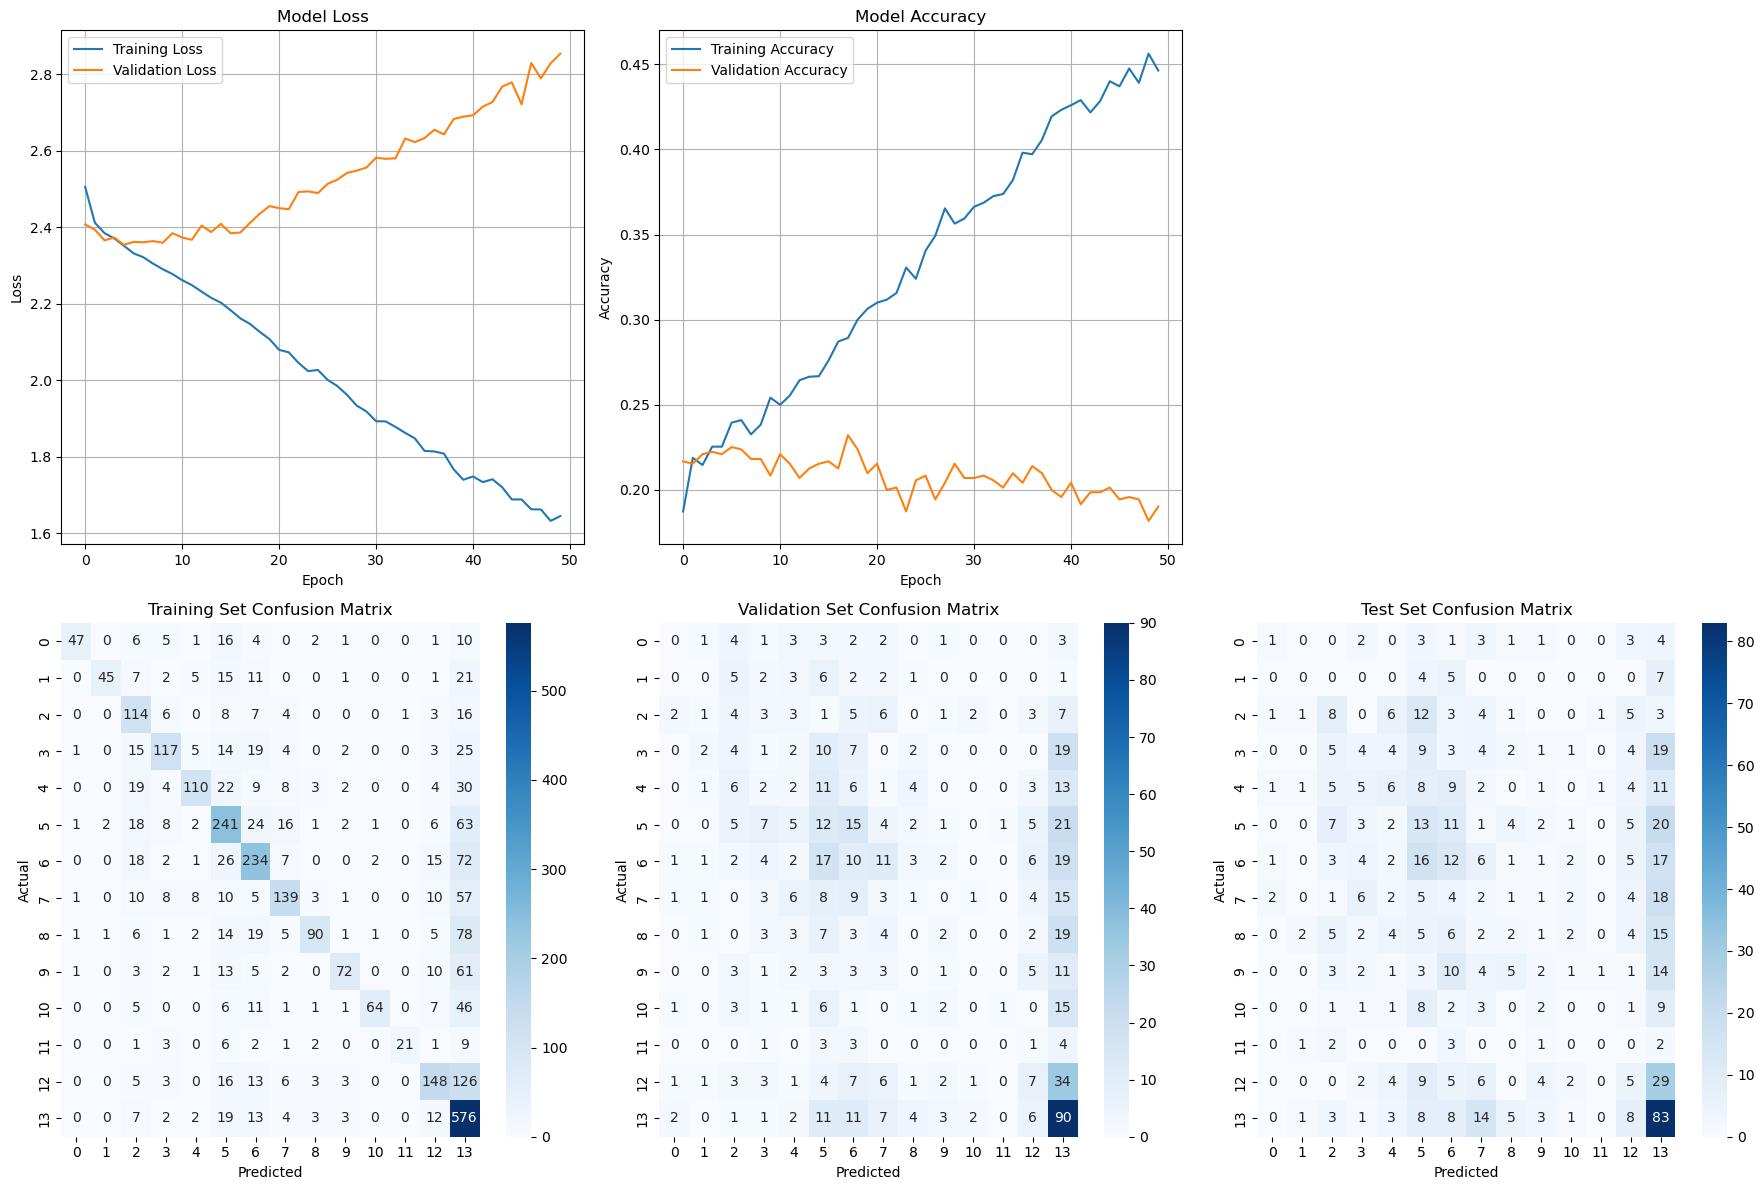

              precision    recall  f1-score   support

           0       0.90      0.51      0.65        93
           1       0.94      0.42      0.58       108
           2       0.49      0.72      0.58       159
           3       0.72      0.57      0.64       205
           4       0.80      0.52      0.63       211
           5       0.57      0.63      0.59       385
           6       0.62      0.62      0.62       377
           7       0.71      0.55      0.62       252
           8       0.83      0.40      0.54       224
           9       0.81      0.42      0.56       170
          10       0.94      0.45      0.61       142
          11       0.95      0.46      0.62        46
          12       0.65      0.46      0.54       323
          13       0.48      0.90      0.63       641

    accuracy                           0.60      3336
   macro avg       0.74      0.54      0.60      3336
weighted avg       0.67      0.60      0.60      3336

              precision  

In [21]:
#Fourth Test (multiclass, val_accuracy)
config4 = {'l1_reg': 0.0, 'l2_reg': 0.0, 'dropout_rate': 0.2, 'hu1': 256, 'hu2': 128,
           'hu3': 64, 'activation': 'relu', 'optimizer': 'adam', 'learning_rate': 0.001,
           'epochs': 50, 'batch_size': 32, 'patience': 10,
           'task': task, 'n_classes': n_classes, 'n_features': X_train.shape[1]}
model4 = DentalClassifier(config4)
model4.train()
results4 = model4.report(model_name="model4_redone_multiclass")
print(results4)

Model Architecture:


/Users/jeffpinarchick/opt/anaconda3/envs/py311/lib/python3.11/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_15"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_60 (Dense)                │ (None, 256)            │        10,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_45 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_61 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_46 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_62 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_47 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_63 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 51,713 (202.00 KB)

 Trainable params: 51,713 (202.00 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
116/116 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8258 - loss: 0.4637 - val_accuracy: 0.8291 - val_loss: 0.4439
Epoch 2/50
116/116 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8304 - loss: 0.4367 - val_accuracy: 0.8291 - val_loss: 0.4354
Epoch 3/50
116/116 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8315 - loss: 0.4256 - val_accuracy: 0.8291 - val_loss: 0.4386
Epoch 4/50
116/116 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8318 - loss: 0.4227 - val_accuracy: 0.8291 - val_loss: 0.4464
Epoch 5/50
116/116 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8326 - loss: 0.4193 - val_accuracy: 0.8291 - val_loss: 0.4456
Epoch 6/50
116/116 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8331 - loss: 0.4119 - val_accuracy: 0.8278 - val_loss: 0.4439
Epoch 7/50
116/116 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8334 - loss: 0.4062 - val_accuracy: 0.8304 - val_loss: 0.4487
Epoch 8/50
116/116 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8339 - loss: 0.4023 - val_accuracy: 0.

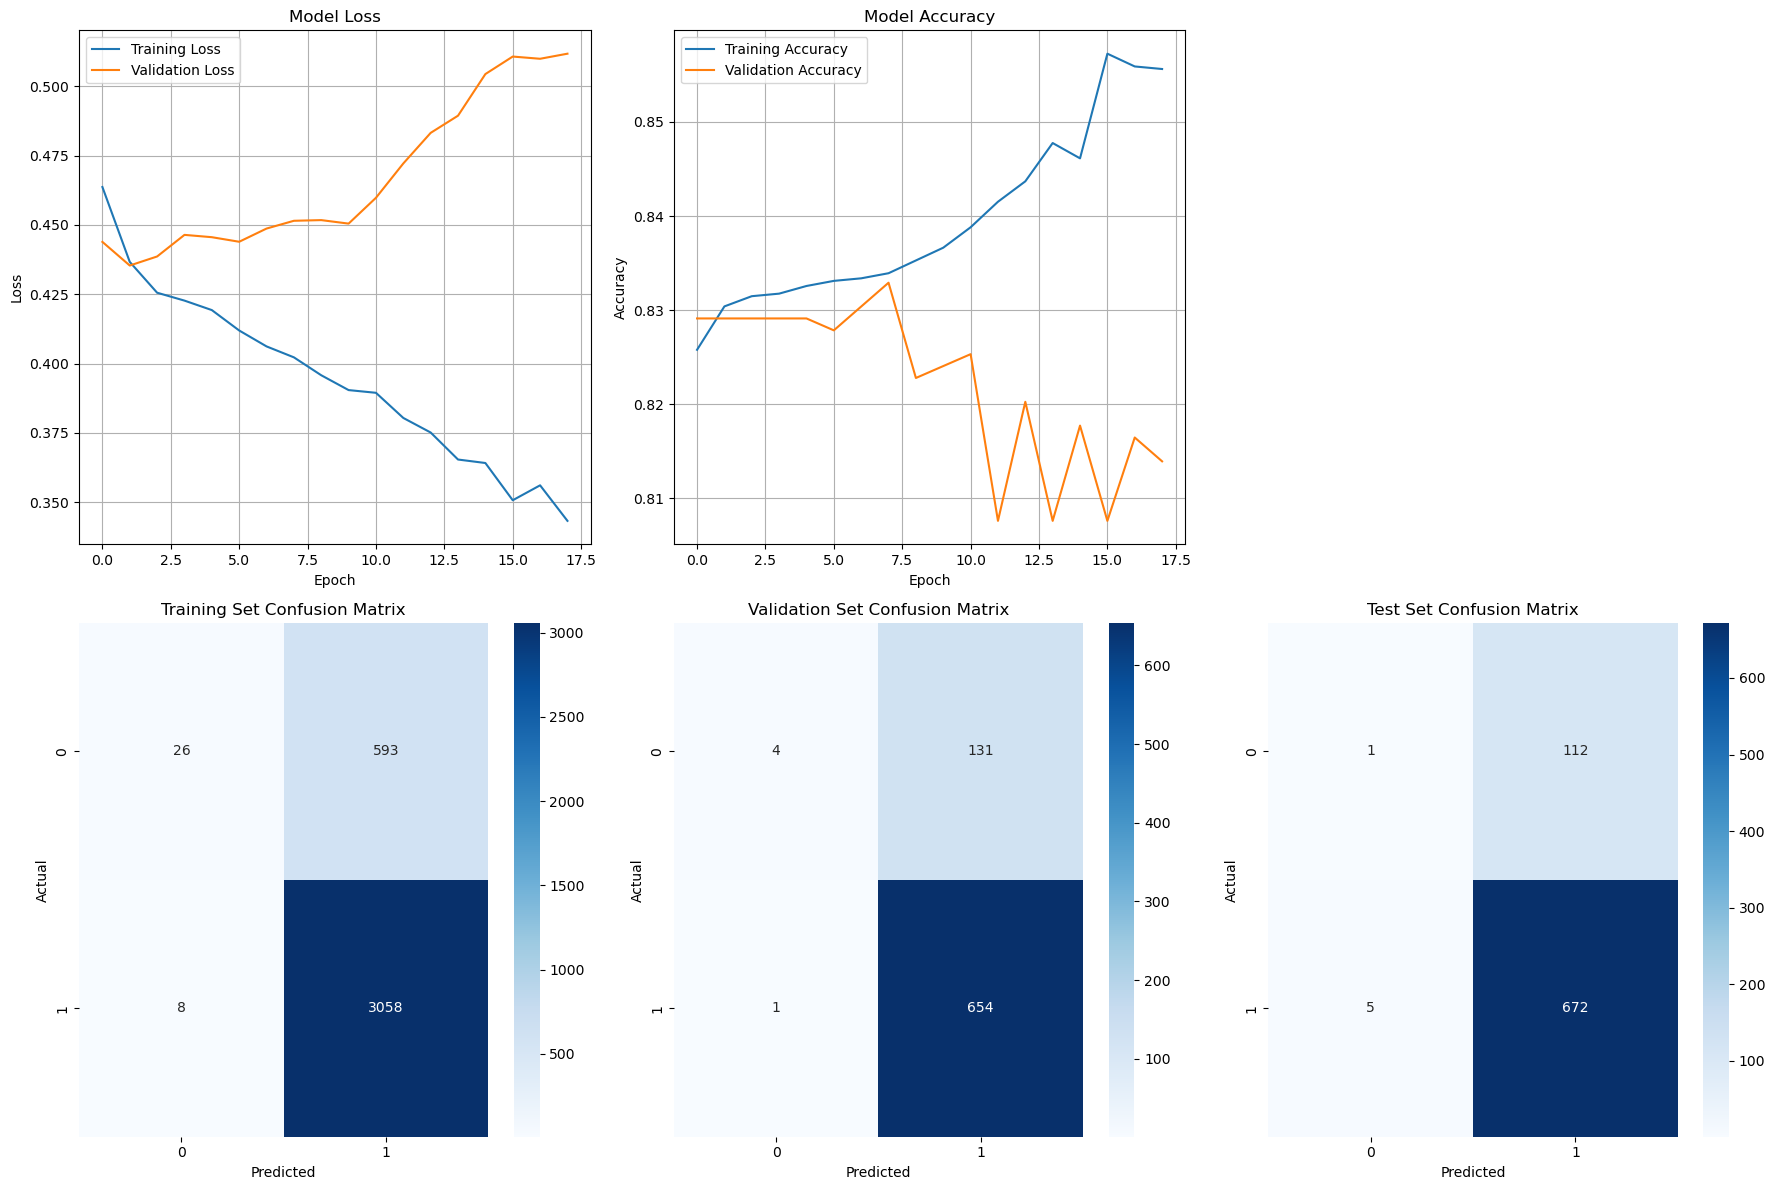

              precision    recall  f1-score   support

           0       0.76      0.04      0.08       619
           1       0.84      1.00      0.91      3066

    accuracy                           0.84      3685
   macro avg       0.80      0.52      0.50      3685
weighted avg       0.83      0.84      0.77      3685

              precision    recall  f1-score   support

           0       0.80      0.03      0.06       135
           1       0.83      1.00      0.91       655

    accuracy                           0.83       790
   macro avg       0.82      0.51      0.48       790
weighted avg       0.83      0.83      0.76       790

              precision    recall  f1-score   support

           0       0.17      0.01      0.02       113
           1       0.86      0.99      0.92       677

    accuracy                           0.85       790
   macro avg       0.51      0.50      0.47       790
weighted avg       0.76      0.85      0.79       790

Training Accuracy: 

In [40]:
#Fifth Test: Updated Binary (val_accuracy)
config5 = {'l1_reg': 0.0, 'l2_reg': 0.0, 'dropout_rate': 0.2, 'hu1': 256, 'hu2': 128,
           'hu3': 64, 'activation': 'relu', 'optimizer': 'adam', 'learning_rate': 0.001,
           'epochs': 50, 'batch_size': 32, 'patience': 10,
           'task': task, 'n_classes': n_classes, 'n_features': X_train.shape[1]}
model5 = DentalClassifier(config5)
model5.train()
results5 = model5.report(model_name="model5_updated_baseline")
print(results5)

Model Architecture:


/Users/jeffpinarchick/opt/anaconda3/envs/py311/lib/python3.11/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_12 (Dense)                │ (None, 256)            │        10,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 51,713 (202.00 KB)

 Trainable params: 51,713 (202.00 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
116/116 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 2.5766 - mae: 1.2747 - val_loss: 2.1939 - val_mae: 1.1646
Epoch 2/50
116/116 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 2.0704 - mae: 1.1514 - val_loss: 2.1026 - val_mae: 1.1522
Epoch 3/50
116/116 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 2.0354 - mae: 1.1562 - val_loss: 2.1723 - val_mae: 1.1719
Epoch 4/50
116/116 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 1.9569 - mae: 1.1263 - val_loss: 2.0410 - val_mae: 1.1365
Epoch 5/50
116/116 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 1.9080 - mae: 1.1189 - val_loss: 2.0410 - val_mae: 1.1392
Epoch 6/50
116/116 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 1.9032 - mae: 1.1165 - val_loss: 2.0950 - val_mae: 1.1416
Epoch 7/50
116/116 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 1.9199 - mae: 1.1151 - val_loss: 2.1004 - val_mae: 1.1416
Epoch 8/50
116/116 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 1.8463 - mae: 1.0987 - val_loss: 2.1987 - val_mae: 1.1610
Epoch 9/50
116/116 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - lo

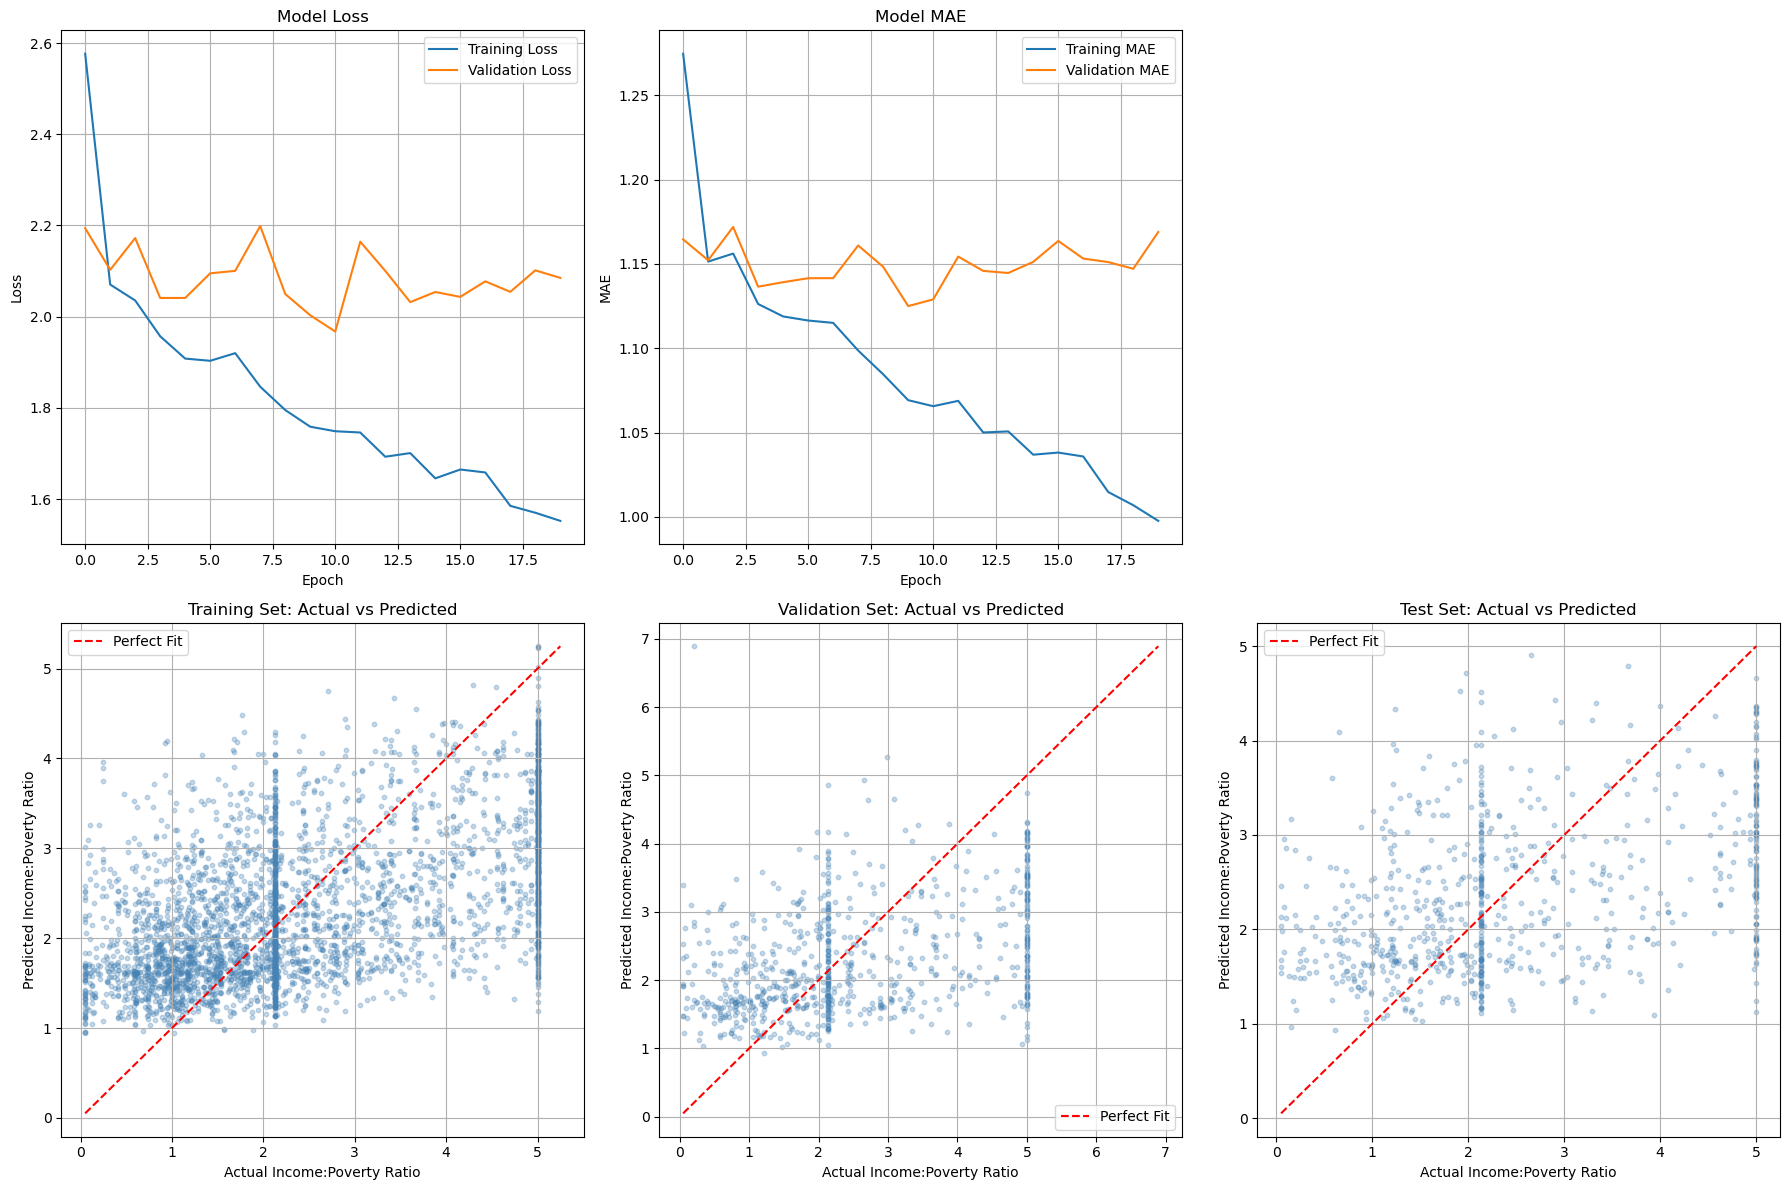

Training   — MAE: 1.0137 | RMSE: 1.2629
Validation — MAE: 1.1250 | RMSE: 1.4153
Test       — MAE: 1.0952 | RMSE: 1.3590
{'train_mae': 1.0137094248793665, 'val_mae': 1.1250269401194175, 'test_mae': 1.095205449249171, 'train_rmse': 1.2628973408127186, 'val_rmse': 1.4152936590779337, 'test_rmse': 1.3590205245323388}


In [13]:
#Sixth Test (regression, val_mae)
config6 = {'l1_reg': 0.0, 'l2_reg': 0.0, 'dropout_rate': 0.2, 'hu1': 256, 'hu2': 128,
           'hu3': 64, 'activation': 'relu', 'optimizer': 'adam', 'learning_rate': 0.001,
           'epochs': 50, 'batch_size': 32, 'patience': 10,
           'task': task, 'n_classes': n_classes, 'n_features': X_train.shape[1]}
model6 = DentalClassifier(config6)
model6.train()
results6 = model6.report(model_name="model6_updated_baseline")
print(results6)